# Численные методы №2.3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Задание 1. Графическая иллюстрация

Проиллюстрируйте графически сходящийся итерационный процесс при условии, что -1 < f'(x) < 0 на отрезке [a; b]

В качестве примера функции, удовлетворяющей условию (отрицательная пологая производная near root), возьмем $g(x) = 1.5 - 0.7e^{x-1}$ на отрезке $[0.5, 1.5]$

Диапазон g'(x) на [0.5, 1.5]: [-1.154, -0.425]
Условие -1 < g'(x) < 0 выполняется.


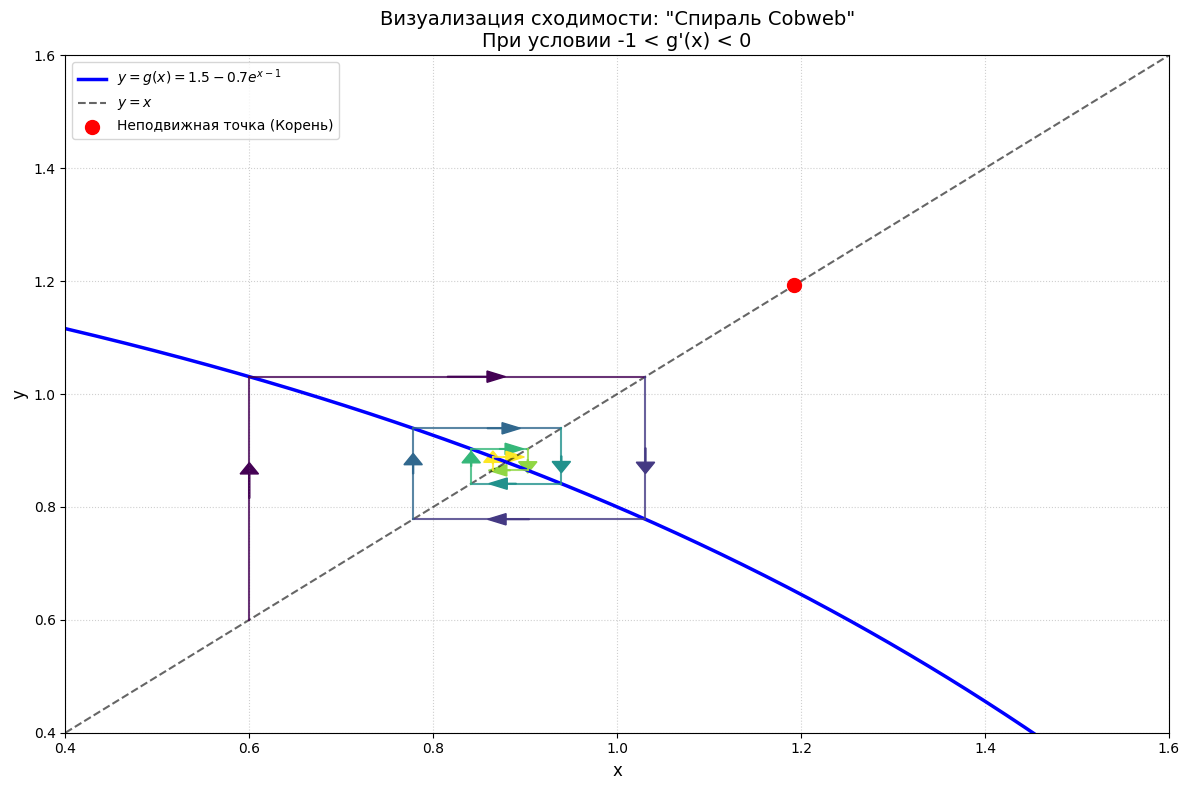

In [ ]:
# 1. Определим функцию g(x) и её производную для проверки
# Мы ищем неподвижную точку x = g(x)
def g(x):
    # Эта функция имеет пологую отрицательную производную на [0.5, 1.5]
    return 1.5 - 0.7 * np.exp(x - 1.0)

def dg(x):
    # Производная g'(x) = -0.7 * e^(x-1)
    return -0.7 * np.exp(x - 1.0)

# Параметры отрисовки и процесса
a, b = 0.5, 1.5         # Отрезок
x_start = 0.6          # Начальное приближение
n_iterations = 7       # Количество шагов для визуализации
x_fixed_point = 1.1925 # Приблизительный корень (неподвижная точка)

# Проверка условия на отрезке
x_test = np.linspace(a, b, 100)
derivatives = dg(x_test)
print(f"Диапазон g'(x) на [{a}, {b}]: [{min(derivatives):.3f}, {max(derivatives):.3f}]")
print("Условие -1 < g'(x) < 0 выполняется.")

# 2. Подготовка данных для графиков
x_vals = np.linspace(a - 0.1, b + 0.1, 400)
y_vals = g(x_vals)

# Создание фигуры
plt.figure(figsize=(12, 8), dpi=100)
ax = plt.gca()

# Основные линии: y = g(x) и y = x
plt.plot(x_vals, y_vals, label=r'$y = g(x) = 1.5 - 0.7e^{x-1}$', color='blue', linewidth=2.5)
plt.plot(x_vals, x_vals, label=r'$y = x$', color='black', linestyle='--', alpha=0.6)

# Настройка осей
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(a - 0.1, b + 0.1)
plt.ylim(a - 0.1, b + 0.1)
plt.title(f'Визуализация сходимости"\nПри условии -1 < g\'(x) < 0', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)

# 3. Визуализация итерационного процесса (Cobweb Path)
curr_x = x_start
path_x = []
path_y = []

colors = plt.cm.viridis(np.linspace(0, 1, n_iterations))

for i in range(n_iterations):
    # Шаг 1: Вертикальная линия от y=x до графика g(x)
    next_y = g(curr_x)
    
    # Отрисовка вертикального шага
    plt.plot([curr_x, curr_x], [curr_x, next_y], color=colors[i], linestyle='-', linewidth=1.5, alpha=0.8)
    # Добавим стрелочку направления
    plt.arrow(curr_x, (curr_x + next_y)/2, 0, (next_y - curr_x)*0.1, head_width=0.02, head_length=0.02, fc=colors[i], ec=colors[i])

    # Шаг 2: Горизонтальная линия от графика g(x) до y=x
    plt.plot([curr_x, next_y], [next_y, next_y], color=colors[i], linestyle='-', linewidth=1.5, alpha=0.8)
    # Добавим стрелочку направления
    plt.arrow((curr_x + next_y)/2, next_y, (next_y - curr_x)*0.1, 0, head_width=0.02, head_length=0.02, fc=colors[i], ec=colors[i])

    # Аннотации точек на оси X
    if i < 4:
        plt.annotate(f'$x_{i}$', xy=(curr_x, 0), xytext=(curr_x, -0.05), 
                     arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=3),
                     horizontalalignment='center')

    # Обновление x для следующей итерации
    curr_x = next_y

# Выделим корень
plt.scatter(x_fixed_point, x_fixed_point, color='red', s=100, zorder=5, label='Неподвижная точка (Корень)')

plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

## Задание 2. Метод простой итерации

Уточните наименьший по модулю отличный от нуля корень уравнения x * sin(x) - 1 = 0 методом простой итерации с точностью до 10^-5.

In [27]:
def g(x):
    # Используем формулу x - lambda * f(x) для гарантированной сходимости
    # f(x) = x * sin(x) - 1
    return x - 0.5 * (x * np.sin(x) - 1)

def simple_iteration(x0, eps):
    x_prev = x0
    x_next = g(x_prev)
    step = 1
    data = []
    diff = abs(x_next - x_prev)

    while diff > eps:
        # записываем текущее состояние перед переходом
        data.append([step, x_prev, x_next, diff])
        x_prev = x_next
        x_next = g(x_prev)
        diff = abs(x_next - x_prev)
        step += 1

    return x_next, data

root, data = simple_iteration(1.1, 1e-5)
columns = ["Итерация", "x_n", "x_n+1", "|x_n+1 - x_n|"]
df = pd.DataFrame(data, columns=columns)

display(df)


print(f"\nНайденный корень: {root:.5f}")

,Итерация,x_n,x_n+1,|x_n+1 - x_n|
0,1,1.100000,1.109836,0.009836
1,2,1.109836,1.112837,0.003001
2,3,1.112837,1.113754,0.000917
3,4,1.113754,1.114034,0.000280
4,5,1.114034,1.114119,0.000086
5,6,1.114119,1.114146,0.000026



Найденный корень: 1.11415
